# mpc_voting.ipynb [CL]

<div class="alert alert-block alert-info">
Notebook Start

**Bank of England: Analysis of Monetary Policy Committee (MPC) Voting on Bank Rate**

**Purpose:**
- Analyse voting trends of the MPC on Bank Rate
- Analyse unaninimity of each vote (especially during crisis periods)

**Scope:**
- Files: xlsx file for mpc voting on bank rate decisions
- Date range: 1998-2022 in a monthly format
- Outputs: dataframe of mpc voting record in a monthly format stored as csv file and charts illustrating trends stored as png files

**Method:**
1. Import libraries and define folder structure
2. Load mpcvoting.xlsx into pandas dataframe
3. Clean dataframe so there are 9 vote columns per month with no missing values
4. Add columns for vote to increase/maintain/decrease bank rate and majority as percentage of total
5. Visualise outputs

**Step 1: Import libraries and define folder structure**

In [1]:
# Import libraries
from pathlib import Path
import re
import pandas as pd
import numpy as np

In [2]:
# Build file paths
root = Path(".")
xlsx_folder = root / "data"
xlsx_file = xlsx_folder / "mpcvoting.xlsx"
out_dir = root / "data" / "mpc_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

**Step 2: Load mpcvoting.xlsx into pandas dataframe**

In [8]:
# Load the mpc_voting.xlsx file into a pandas dataframe only taking necessary sheet and rows
mpcvoting_df = pd.read_excel(
    xlsx_file,
    sheet_name="Bank Rate Decisions",
    usecols="B:L, N:BC",
    skiprows=18,
    nrows=300,
    header=None)

# New names for first 11 columns
new_names = ["Date",
             "Bank Rate",
             "Vote 1",
             "Vote 2",
             "Vote 3",
             "Vote 4",
             "Vote 5",
             "Vote 6",
             "Vote 7",
             "Vote 8",
             "Vote 9"]

# Apply the new names ONLY to the first 11 columns
mpcvoting_df.columns = new_names + list(mpcvoting_df.columns[11:])

In [9]:
# Preview the dataframe
print(mpcvoting_df.head())
print(mpcvoting_df.tail())
print(mpcvoting_df.shape)

        Date  Bank Rate  Vote 1  Vote 2  Vote 3  Vote 4  Vote 5  Vote 6  \
0 1998-01-08     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
1 1998-02-05     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
2 1998-03-05     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
3 1998-04-09     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   
4 1998-05-07     0.0725     NaN     NaN     NaN     NaN     NaN     NaN   

   Vote 7  Vote 8  ...  45  46  47  48  49  50  51  52  53  54  
0     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
1     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
2     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
3     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  
4     NaN     NaN  ... NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  

[5 rows x 53 columns]
          Date  Bank Rate  Vote 1  Vote 2  Vote 3  Vote 4  Vote 5  Vote 6  \
295 2025-03-20     0.0450  0.0450  0.0450  0.0425  0.0450  

**Results of step 2:**
- Only rows and columns containing votes loaded into pandas dataframe
- Initial dataframe shows 300 rows and 53 columns
- Names added to first 11 columns which will be populated on cleaning, other 42 columns will be deleted after cleaning

**Step 3: Clean dataframe so there are 9 vote columns per month with no missing values**

In [10]:
# Identify all vote columns from file
vote_columns = mpcvoting_df.columns[2:]

In [11]:
# Define a function to collapse all votes into 9 columns
def collapse_votes(row):
    # extract all vote values from the many MPC-member columns
    votes = [v for v in row[vote_columns].tolist() if pd.notna(v)]
    votes = votes[:9]  # keep only the first 9
    
    # pad if fewer than 9 votes (rare)
    votes += [None] * (9 - len(votes))
    
    return pd.Series(votes, index=[f"vote {i}" for i in range(1, 10)])

In [12]:
# Apply the function to each row
new_votes_df = mpcvoting_df.apply(collapse_votes, axis=1)

In [14]:
# Create the final clean data frame
final_df = pd.concat(
    [mpcvoting_df[["Date", "Bank Rate"]], new_votes_df],
    axis=1)

In [15]:
# Rename the final data frame
mpcvoting_clean = final_df

# Preview the clean data frame
print(mpcvoting_clean.head())
print(mpcvoting_clean.tail())
print(mpcvoting_clean.shape)
print(mpcvoting_clean.dtypes)

        Date  Bank Rate    vote 1    vote 2  vote 3  vote 4    vote 5  \
0 1998-01-08     0.0725  Increase  Increase  0.0725  0.0725  Increase   
1 1998-02-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
2 1998-03-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
3 1998-04-09     0.0725  Increase  Increase  0.0725  0.0725    0.0725   
4 1998-05-07     0.0725    0.0725  Increase  0.0725  0.0725    0.0725   

     vote 6    vote 7  vote 8  vote 9  
0    0.0725    0.0725  0.0725     NaN  
1    0.0725  Increase  0.0725     NaN  
2    0.0725  Increase  0.0725     NaN  
3    0.0725  Increase  0.0725     NaN  
4  Decrease    0.0725  0.0725     NaN  
          Date  Bank Rate  vote 1  vote 2  vote 3  vote 4  vote 5  vote 6  \
295 2025-03-20     0.0450   0.045   0.045  0.0425  0.0450   0.045   0.045   
296 2025-05-08     0.0425  0.0425  0.0425  0.0400  0.0425  0.0425   0.045   
297 2025-06-19     0.0425  0.0425  0.0425  0.0400  0.0425  0.0425  0.0425   
298 2025-08-0

In [16]:
# Replace missing values with bank rate at the time
vote_cols = [f"vote {i}" for i in range(1, 10)]

for col in vote_cols:
    mpcvoting_clean[col] = mpcvoting_clean[col].fillna(mpcvoting_clean["Bank Rate"])

In [17]:
# Preview the clean data frame
print(mpcvoting_clean.head())

        Date  Bank Rate    vote 1    vote 2  vote 3  vote 4    vote 5  \
0 1998-01-08     0.0725  Increase  Increase  0.0725  0.0725  Increase   
1 1998-02-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
2 1998-03-05     0.0725  Increase  Increase  0.0725  0.0725  Increase   
3 1998-04-09     0.0725  Increase  Increase  0.0725  0.0725    0.0725   
4 1998-05-07     0.0725    0.0725  Increase  0.0725  0.0725    0.0725   

     vote 6    vote 7  vote 8  vote 9  
0    0.0725    0.0725  0.0725  0.0725  
1    0.0725  Increase  0.0725  0.0725  
2    0.0725  Increase  0.0725  0.0725  
3    0.0725  Increase  0.0725  0.0725  
4  Decrease    0.0725  0.0725  0.0725  


In [18]:
# Convert "Increase" and "Decrease" to numeric values
def normalize_vote(vote, bank_rate):
    if pd.isna(vote):
        return vote  # leave NaN for now (you already handle NaNs later)

    if isinstance(vote, str):
        if vote.strip().lower() == "increase":
            return bank_rate + 0.0025
        elif vote.strip().lower() == "decrease":
            return bank_rate - 0.0025
        elif vote.strip().lower() in ["maintain", "hold"]:
            return bank_rate
        else:
            # If it is a number stored as a string, convert it
            try:
                return float(vote)
            except:
                return vote  # unexpected string, leave unchanged
        
    # If it is already numeric, return as is
    return vote

In [20]:
# Apply to all rows
for col in vote_cols:
    mpcvoting_clean[col] = mpcvoting_clean.apply(
        lambda row: normalize_vote(row[col], row["Bank Rate"]),
        axis=1)

In [21]:
# View the data frame
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725


In [23]:
# Filter out dates on or after 2023-01-01 so that only values for pre-established date range are included
cutoff_date = pd.Timestamp("2023-01-01")
mpcvoting_clean = mpcvoting_clean[mpcvoting_clean["Date"] < cutoff_date]

In [24]:
# View last 5 rows
mpcvoting_clean.tail()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9
273,2022-06-16,0.0125,0.0125,0.0150,0.0125,0.0125,0.0125,0.0125,0.0150,0.0150,0.0125
274,2022-08-04,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0175,0.0150
275,2022-09-22,0.0225,0.0225,0.0200,0.0250,0.0225,0.0250,0.0225,0.0225,0.0250,0.0225
276,2022-11-03,0.0300,0.0300,0.0275,0.0300,0.0300,0.0300,0.0300,0.0300,0.0300,0.0250
277,2022-12-15,0.0350,0.0350,0.0300,0.0375,0.0350,0.0350,0.0350,0.0350,0.0350,0.0300


**Results of step 3:**
- Voting columns were established and function was defined to collapse all votes into 9 columns
- For months where there were fewer than 9 members of the MPC, missing votes were assumed to be bank rate at the time
- Where votes were labled as "Increase"/"Decrease"/"Maintain"/"Hold" an increase/decrease of the bank rate was assumed to be 0.25% and maintain was set as the current bank rate
- Any votes held on or after 1st January 2023 were filtered out to correspond with pre-established date range
- Data frame was saved to csv file

**Step 4: Add columns for vote to increase/maintain/decrease bank rate and majority as percentage of total**

In [7]:
# Specify vote columns
vote_cols = mpcvoting_clean.columns[2:]

# View vote_cols
vote_cols

Index(['vote 1', 'vote 2', 'vote 3', 'vote 4', 'vote 5', 'vote 6', 'vote 7',
       'vote 8', 'vote 9'],
      dtype='object')

In [8]:
# Calculate the mode of vote_cols for every row and add to new majority_vote column
mpcvoting_clean["majority_vote"] = (mpcvoting_clean[vote_cols].mode(axis=1).iloc[:, 0])

# Preview first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725


In [15]:
# Add new decision column based on majority_vote and Bank Rate of previous row
prev_bank_rate = mpcvoting_clean["Bank Rate"].shift(1)

conditions = [
    mpcvoting_clean["majority_vote"] > prev_bank_rate,
    mpcvoting_clean["majority_vote"] == prev_bank_rate,
    mpcvoting_clean["majority_vote"] < prev_bank_rate
]

choices = ["increase", "maintain", "decrease"]

mpcvoting_clean["decision"] = np.select(conditions, choices, default="maintain")

# View first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778


In [16]:
# Calculate majority_vote as percentage of total votes to determine unanimity of vote
vote_count = len(vote_cols)

mpcvoting_clean["majority_vote_pct"] = (
    (mpcvoting_clean[vote_cols]
        .eq(mpcvoting_clean["majority_vote"], axis=0)
        .sum(axis=1)
      / vote_count) 
    * 100)

# View first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778


In [22]:
# Convert the decision to a numeric value
decision_map = {"increase": 1, "maintain": 0, "decrease": -1}
mpcvoting_clean["decision_numeric"] = mpcvoting_clean["decision"].map(decision_map)

# View the first 5 rows
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct,decision_numeric
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667,0
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667,0
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778,0


In [23]:
# Save the dataframe to a csv file
# Ensure the folder exists
out_dir.mkdir(parents=True, exist_ok=True)

# Define the CSV file path
output_file = out_dir / "mpcvoting_clean.csv"

# Save the DataFrame
mpcvoting_clean.to_csv(output_file, index=False)

**Results of step 4:**
- The majority vote for each month was calculated using the mode of columns containing votes
- The decision to increase/maintain/decrease the bank rate was calculated using a comparison of the majority vote and the bank rate of the previous month and stored as a numeric value (1 to -1)
- The majority as a percentage of the total vote was calculated for each month to determine the unanimity of each vote

**Step 5: Visualise outputs**

In [3]:
# Import libraries
import matplotlib.pyplot as plt

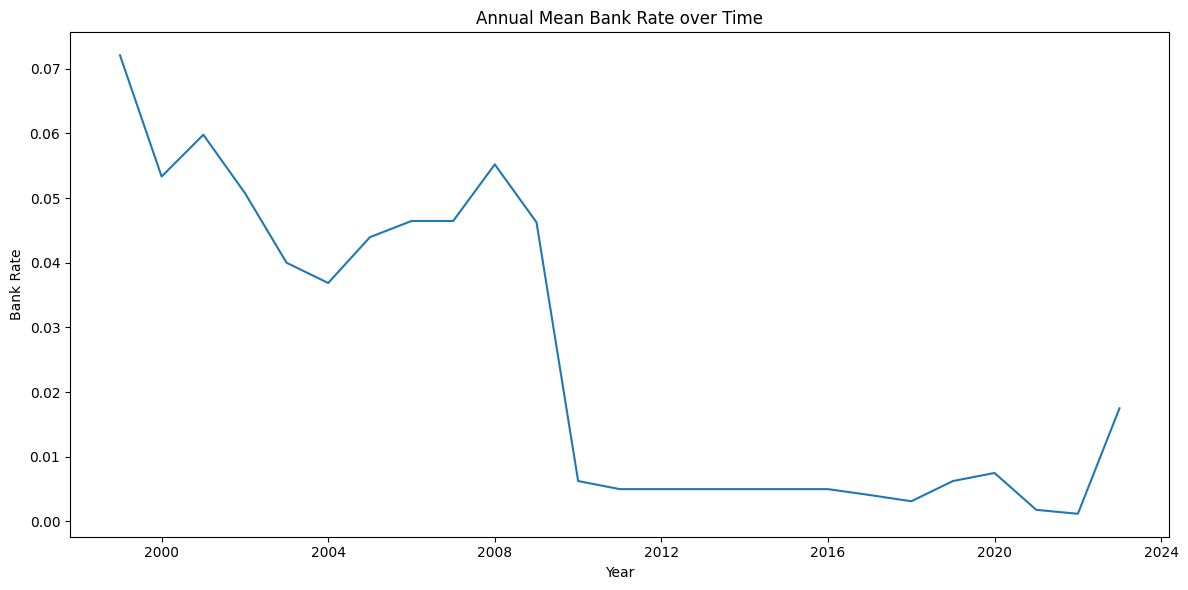

In [28]:
# Ensure Date column is datetime
mpcvoting_clean["Date"] = pd.to_datetime(mpcvoting_clean["Date"])

# Filter out dates after 31st Dec 2022
mask = (mpcvoting_clean["Date"] <= "2022-12-31")
mpcvoting_22 = mpcvoting_clean.loc[mask].sort_values("Date")

# Set Date as index
mpcvoting_22 = mpcvoting_22.set_index("Date")

# Compute annual mean
annual_mean_bankrate = mpcvoting_22.resample("YE")["Bank Rate"].mean()

# Define plot size
plt.figure(figsize=(12, 6))

# Plot points
plt.plot(annual_mean_bankrate.index, annual_mean_bankrate.values)

# Labels
plt.xlabel("Year")
plt.ylabel("Bank Rate")
plt.title("Annual Mean Bank Rate over Time")

plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "annual_mean_bank_rate.png", dpi=300)

# Print the plot
plt.show()

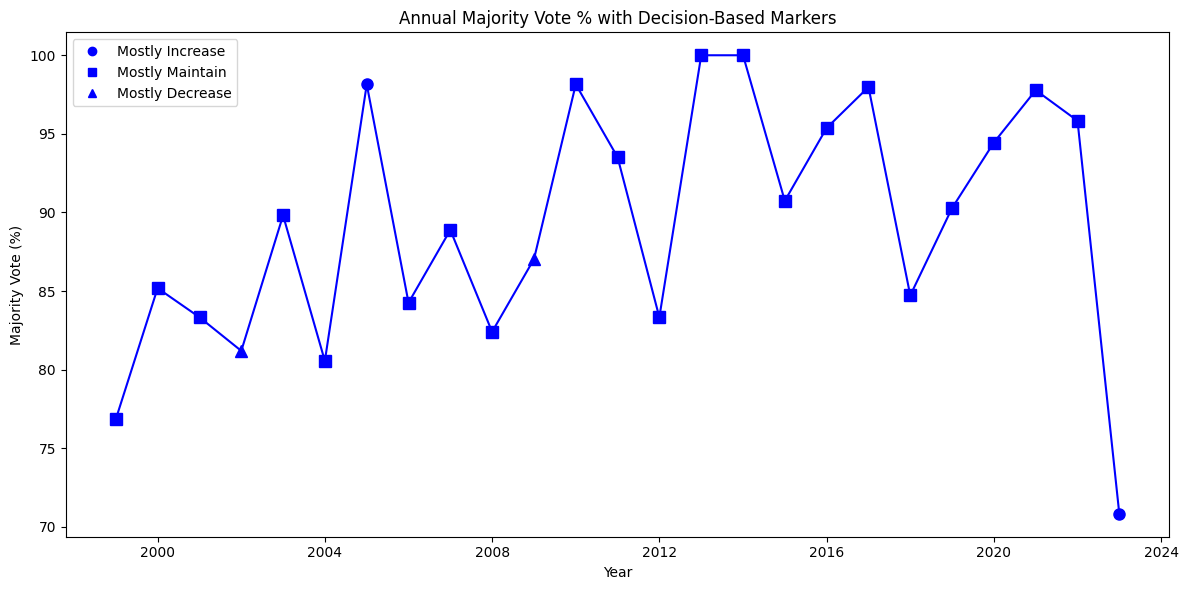

In [27]:
# Convert index to datetime if needed
mpcvoting_clean.index = pd.to_datetime(mpcvoting_clean.index, errors="coerce")

# Compute annual mean
annual_mean = mpcvoting_clean.resample("YE")[["majority_vote_pct", "decision_numeric"]].mean()

# Define marker based on decision_numeric thresholds
def decision_marker(value):
    if value > 0.33:
        return "o"   # mostly increase
    elif value < -0.33:
        return "^"   # mostly decrease
    else:
        return "s"   # mostly maintain

# Define plot size
plt.figure(figsize=(12, 6))

# Plot each point individually with its marker
for date, row in annual_mean.iterrows():
    plt.plot(
        date,
        row["majority_vote_pct"],
        marker=decision_marker(row["decision_numeric"]),
        markersize=8,
        color="blue",
        linestyle="-"
    )

# Connect points with a line
plt.plot(annual_mean.index, annual_mean["majority_vote_pct"], color="blue", linestyle="-")

# Labels and formatting
plt.xlabel("Year")
plt.ylabel("Majority Vote (%)")
plt.title("Annual Majority Vote % with Decision-Based Markers")

# Create a custom legend for the markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="blue", label="Mostly Increase", linestyle=""),
    Line2D([0], [0], marker="s", color="blue", label="Mostly Maintain", linestyle=""),
    Line2D([0], [0], marker="^", color="blue", label="Mostly Decrease", linestyle="")
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote_unanimity.png", dpi=300)

# Print the plot
plt.show()

In [17]:
# Reload old version of mpcvoting_clean.csv with Date column rather than date as index
mpcvoting_clean = pd.read_csv(output_file)

# Check that csv file has been loaded correctly
mpcvoting_clean.head()

,Date,Bank Rate,vote 1,vote 2,vote 3,vote 4,vote 5,vote 6,vote 7,vote 8,vote 9,majority_vote,decision,majority_vote_pct,decision_numeric
0,1998-01-08,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,0.0725,0.0725,maintain,66.666667,0
1,1998-02-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
2,1998-03-05,0.0725,0.0750,0.075,0.0725,0.0725,0.0750,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,55.555556,0
3,1998-04-09,0.0725,0.0750,0.075,0.0725,0.0725,0.0725,0.0725,0.0750,0.0725,0.0725,0.0725,maintain,66.666667,0
4,1998-05-07,0.0725,0.0725,0.075,0.0725,0.0725,0.0725,0.0700,0.0725,0.0725,0.0725,0.0725,maintain,77.777778,0


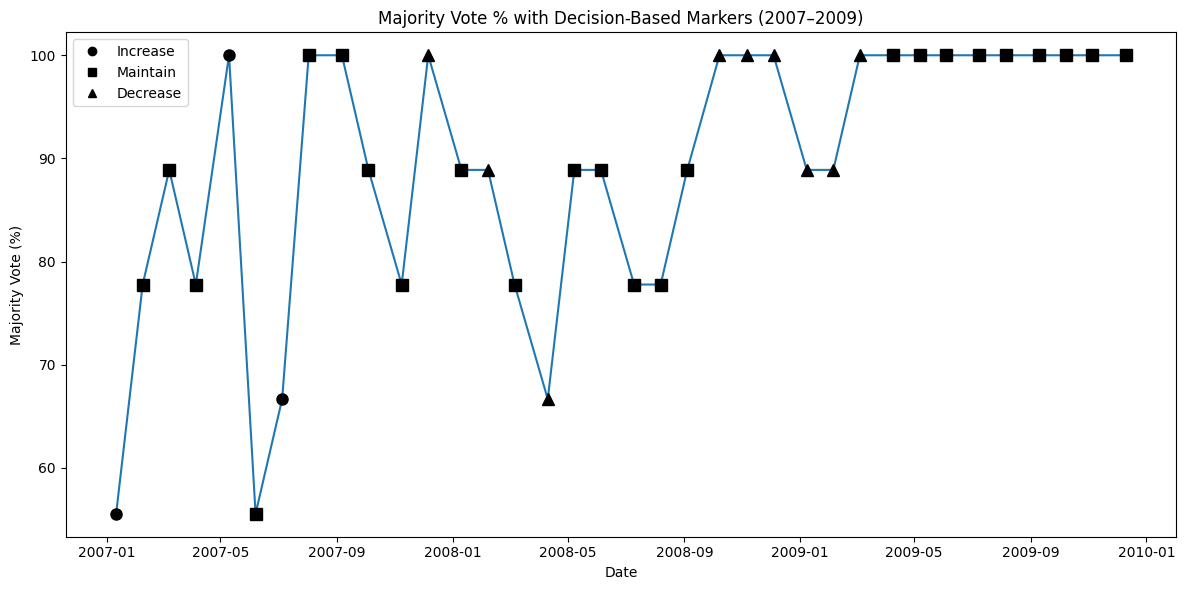

In [11]:
# Ensure Date is datetime
mpcvoting_clean["Date"] = pd.to_datetime(mpcvoting_clean["Date"], errors="coerce")

# Filter for 2007–2009
mask = (mpcvoting_clean["Date"] >= "2007-01-01") & (mpcvoting_clean["Date"] <= "2009-12-31")
df_0709 = mpcvoting_clean.loc[mask].sort_values("Date")

# Map decisions to markers
marker_map = {
    "increase": "o",   # circle
    "maintain": "s",   # square
    "decrease": "^"    # triangle
}

# Define plot size
plt.figure(figsize=(12, 6))

# Plot the line first (without markers)
plt.plot(df_0709["Date"], df_0709["majority_vote_pct"], linestyle="-")

# Scatter individual points with decision-based markers
for _, row in df_0709.iterrows():
    plt.plot(
        row["Date"],
        row["majority_vote_pct"],
        marker=marker_map.get(row["decision"], "o"), 
        markersize=8,
        linestyle="",
        color="black"
    )

# Labels and formatting
plt.xlabel("Date")
plt.ylabel("Majority Vote (%)")
plt.title("Majority Vote % with Decision-Based Markers (2007–2009)")

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='black', linestyle='', label='Increase'),
    Line2D([0], [0], marker='s', color='black', linestyle='', label='Maintain'),
    Line2D([0], [0], marker='^', color='black', linestyle='', label='Decrease')
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote0709_unanimity.png", dpi=300)

# Print the plot
plt.show()

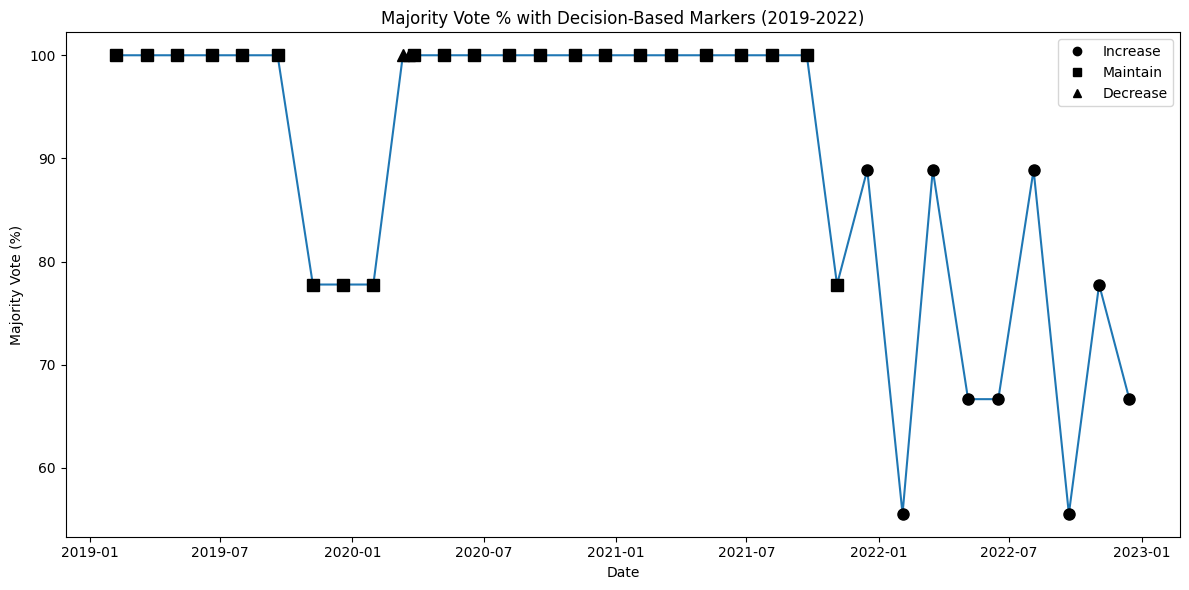

In [12]:
# Filter for 2019–2022
mask = (mpcvoting_clean["Date"] >= "2019-01-01") & (mpcvoting_clean["Date"] <= "2022-12-31")
df_1922 = mpcvoting_clean.loc[mask].sort_values("Date")

# Map decisions to markers
marker_map = {
    "increase": "o",   # circle
    "maintain": "s",   # square
    "decrease": "^"    # triangle
}

# Define plot size
plt.figure(figsize=(12, 6))

# Plot the line first (without markers)
plt.plot(df_1922["Date"], df_1922["majority_vote_pct"], linestyle="-")

# Scatter individual points with decision-based markers
for _, row in df_1922.iterrows():
    plt.plot(
        row["Date"],
        row["majority_vote_pct"],
        marker=marker_map.get(row["decision"], "o"), 
        markersize=8,
        linestyle="",
        color="black"
    )

# Labels and formatting
plt.xlabel("Date")
plt.ylabel("Majority Vote (%)")
plt.title("Majority Vote % with Decision-Based Markers (2019-2022)")

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='black', linestyle='', label='Increase'),
    Line2D([0], [0], marker='s', color='black', linestyle='', label='Maintain'),
    Line2D([0], [0], marker='^', color='black', linestyle='', label='Decrease')
]
plt.legend(handles=legend_elements)
plt.tight_layout()

# Save the plot as a PNG file
plt.savefig(out_dir / "mpcvote1922_unanimity.png", dpi=300)

# Print the plot
plt.show()

**Results of stage 5:**
- 1st graph showing annual mean bank rate over time drawn by calculating annual mean bank rate and plotting against year
- 2nd graph showing annual majority vote drawn by calculating average majority vote percentage and avergae decision for each year
- 3rd graph focusing on 2007-09, around the GFC, drawn by creating subset of data frame and plotting majority vote percentage against date with decision as marker
- 4th graph focusing on 2019-22, around COVID pandemic, drawn using same method as 3rd graph

**Conclusions drawn from analysis:**
- The bank rate was historically high, had a big decrease after the peak of the GFC and remained low until after the height of the COVID pandemic, where it has begun to rise again
- When looking at yearly averages of majority vote as a percentage of total votes, there is always at least a 70% majority and a 100% majority in 2 consecutive years
- In 21 out of the 25 years, the average decision was to maintain the bank rate. This shows that the mpc prefer to keep the bank rate steady within any given year
- When focusing on the period around the GFC, the unanimity of the vote varies greatly and the decision of the vote is less consistent. At the beginning of the crisis in 2007, the unanimity fluctuates from low points of 55% to high points of 100%, with the decision being to either maintain or increase the bank rate. During the peak of the crisis in 2008 the unanimity of the vote is more certain, ranging between 70% and 100%, with the decision being either to maintain or decrease the bank rate. After the peak of the crisis in 2009 the majority was much more stable, hitting 100% from March onwards, and the decision to maintain the bank rate was consistent from April onwards.
- When focusing on the period around the COVID pandemic, the unanimity shows little variation until the recovery period after the easing of lockdown restrictions. The bank voted unanimously to maintain the bank rate for the majority of 2019. There was a decrease at the beginning of the first lockdown in March 2020, and then the bank voted unanimously to maintain the bank rate for the rest of 2020 and until after the easing of lockdown restrictions in mid 2021. From the summer of 2021 to the end of 2022, as the UK recovered from the various lockdown restrictions, the majority of the mpc's vote was less certain ranging from 55% to 90%, but the decision to increase the bank rate again was consistent
- The mpc's reactions to the two crisis periods was different, the unanimity varies in one whereas it was very stable in another. Their decisions tend to be to maintain the bank rate during a crisis period, only increasing it as the economy begins to recover afterwards

<div class="alert alert-block alert-info">
Notebook End